# TP2 (a completer) : Arbre de decision — *Pima Diabetes*

Remplacez chaque `...` et chaque `# TODO`. Le corrige
(`../notebooks/TP2_arbre_decision.ipynb`) applique la **meme demarche sur un
AUTRE dataset (Breast Cancer)** : la structure est identique, seules les donnees
et les colonnes changent : a vous d'adapter.

**Objectif.** Predire si une patiente est **diabetique** avec un arbre
**interpretable**, et evaluer en privilegiant le **rappel sur les cas diabetiques**.

In [23]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [3]:
from sklearn.datasets import fetch_openml
ds = fetch_openml(name="diabetes", version=1, as_frame=True)   # telecharge une fois puis cache
X = ds.data                                  # 8 mesures medicales (preg, plas, pres, ...)
y = (ds.target == "tested_positive").astype(int)
CLASSES = ["non_diabetique", "diabetique"]   # 0 = negatif, 1 = positif
print(X.shape, CLASSES)

(768, 8) ['non_diabetique', 'diabetique']


## 1. Exploration
**Consigne.** Affichez la repartition des classes (combien de diabetiques / non).

In [4]:
y.value_counts().rename(index={0: CLASSES[0], 1: CLASSES[1]})

,count
class,
non_diabetique,500
diabetique,268


## 2. Modelisation
**Consigne.** Separez en train/test (25% test, `stratify=y`, `random_state=42`),
puis entrainez un `DecisionTreeClassifier` (`max_depth=3`, `min_samples_leaf=10`).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
# TODO : creer et entrainer l'arbre
arbre = DecisionTreeClassifier(max_depth=3,min_samples_leaf=10,criterion="gini")
arbre.fit(X_train,y_train)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=10)

In [6]:
from sklearn.ensemble import RandomForestClassifier
# TODO : creer et entrainer random
random =  RandomForestClassifier(max_depth=5,min_samples_leaf=10,criterion="gini")
random.fit(X_train,y_train)


RandomForestClassifier(max_depth=5, min_samples_leaf=10)

In [7]:
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1)

In [8]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

### Évaluation de XGBoost

XGBoost score train : 0.953125
XGBoost score test : 0.7291666666666666
                precision    recall  f1-score   support

non_diabetique       0.78      0.82      0.80       125
    diabetique       0.62      0.57      0.59        67

      accuracy                           0.73       192
     macro avg       0.70      0.69      0.70       192
  weighted avg       0.72      0.73      0.73       192



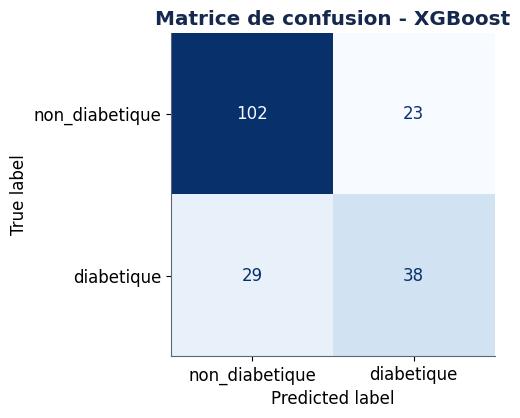

In [19]:
print(f"XGBoost score train : {xgb.score(X_train,y_train)}")
print(f"XGBoost score test : {xgb.score(X_test,y_test)}")
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test,y_pred_xgb,target_names=CLASSES))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.set_title("Matrice de confusion - XGBoost")
ConfusionMatrixDisplay(cm_xgb, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 3. Evaluation
**Consigne.** Affichez l'accuracy train et test, le `classification_report`
(avec `target_names=CLASSES`) et la **matrice de confusion**. Commentez le
**rappel** de la classe `diabetique`.

### Évaluation de l'Arbre de Décision

arbre score train : 0.7829861111111112
arbre score test : 0.7135416666666666
                precision    recall  f1-score   support

non_diabetique       0.75      0.84      0.79       125
    diabetique       0.62      0.48      0.54        67

      accuracy                           0.71       192
     macro avg       0.68      0.66      0.67       192
  weighted avg       0.70      0.71      0.70       192



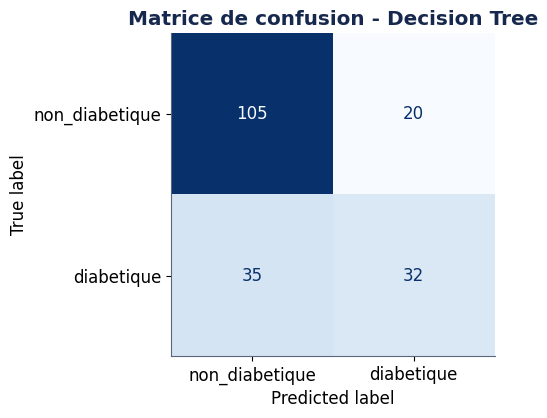

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# TODO : accuracy train / test
print(f"arbre score train : {arbre.score(X_train,y_train)}")
print(f"arbre score test : {arbre.score(X_test,y_test)}")
y_pred = arbre.predict(X_test)
# TODO : afficher classification_report
print(classification_report(y_test,y_pred,target_names=CLASSES))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.set_title("Matrice de confusion - Decision Tree")
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

### Évaluation de la Forêt Aléatoire

random score train : 0.8350694444444444
random score test : 0.734375
                precision    recall  f1-score   support

non_diabetique       0.75      0.84      0.79       125
    diabetique       0.62      0.48      0.54        67

      accuracy                           0.71       192
     macro avg       0.68      0.66      0.67       192
  weighted avg       0.70      0.71      0.70       192



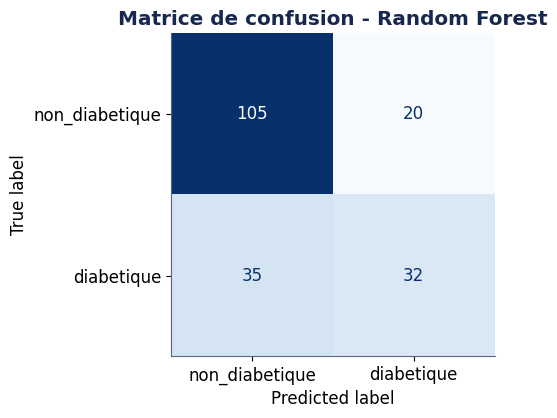

In [11]:

print(f"random score train : {random.score(X_train,y_train)}")
print(f"random score test : {random.score(X_test,y_test)}")
y_pred = arbre.predict(X_test)
# TODO : afficher classification_report
print(classification_report(y_test,y_pred,target_names=CLASSES))
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.set_title("Matrice de confusion - Random Forest")
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.show()

## 4. Visualisation
**Consigne.** Tracez l'arbre (`plot_tree`) puis l'**importance des variables**
(barres horizontales des `feature_importances_` non nulles).

### Visualisation de l'Arbre de Décision

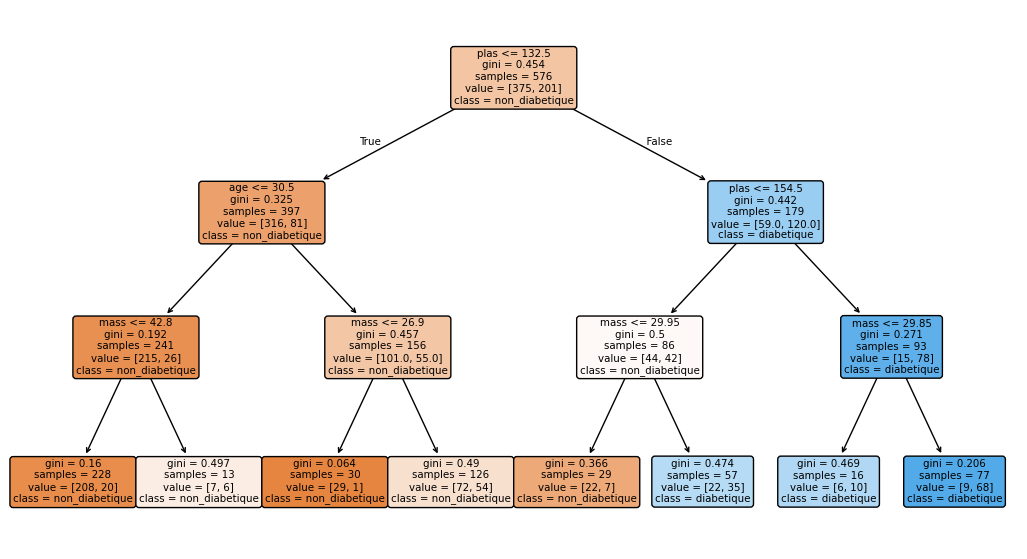

In [12]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(13, 7))
plot_tree(arbre, feature_names=list(X.columns), class_names=CLASSES, filled=True, rounded=True,ax=ax)
plt.show()

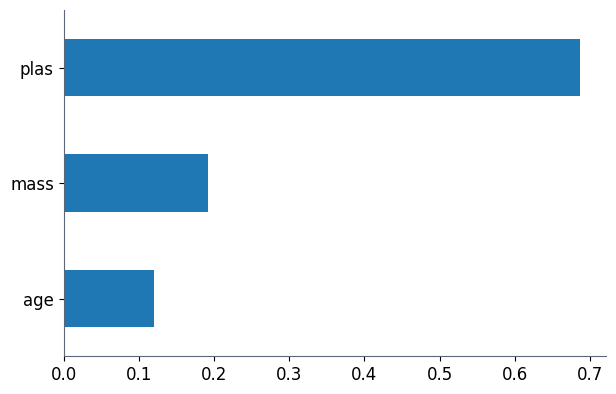

In [13]:
# DECISION TREE
imp = pd.Series(arbre.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
# TODO : barh de imp
...
imp.plot.barh()
plt.show()

### Visualisation de la Forêt Aléatoire

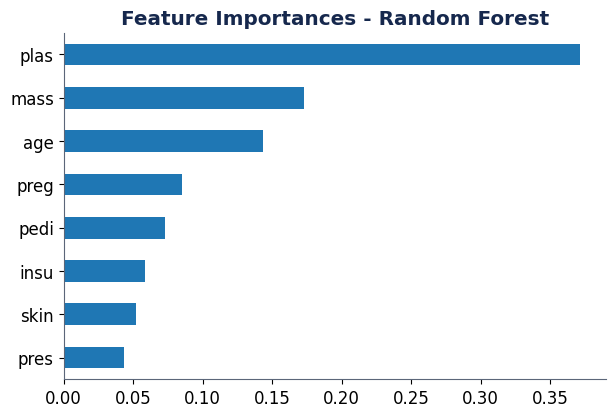

In [15]:
imp = pd.Series(random.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()
imp.plot.barh()
plt.title("Feature Importances - Random Forest")
plt.show()

### Visualisation du XGBoost

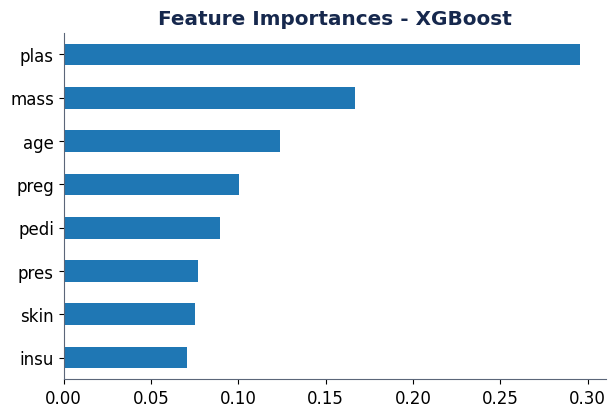

In [14]:
imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
imp_xgb = imp_xgb[imp_xgb > 0].sort_values()
imp_xgb.plot.barh()
plt.title("Feature Importances - XGBoost")
plt.show()

## 5. Prise de decision
**Consigne.** Sur 5 cas du test, affichez diagnostic reel, predit et
`predict_proba` de la classe diabetique.

In [16]:
#Decision Forest
ech = X_test.head(5)
y_pred_ech = arbre.predict(ech)
y_proba_ech = arbre.predict_proba(ech)

df_ech = pd.DataFrame({
    'real': y_test.head(5).map({0: CLASSES[0], 1: CLASSES[1]}),
    'predicted': pd.Series(y_pred_ech).map({0: CLASSES[0], 1: CLASSES[1]}).values,
    'proba_diabetique': y_proba_ech[:, 1]
}, index=ech.index)
display(df_ech)

,real,predicted,proba_diabetique
635,diabetique,non_diabetique,0.428571
698,non_diabetique,non_diabetique,0.087719
637,non_diabetique,non_diabetique,0.087719
402,diabetique,diabetique,0.614035
425,diabetique,diabetique,0.883117


In [17]:
#Random Forest
ech = X_test.head(5)
y_pred_ech = random.predict(ech)
y_proba_ech = random.predict_proba(ech)

df_ech = pd.DataFrame({
    'real': y_test.head(5).map({0: CLASSES[0], 1: CLASSES[1]}),
    'predicted': pd.Series(y_pred_ech).map({0: CLASSES[0], 1: CLASSES[1]}).values,
    'proba_diabetique': y_proba_ech[:, 1]
}, index=ech.index)
display(df_ech)

,real,predicted,proba_diabetique
635,diabetique,non_diabetique,0.378623
698,non_diabetique,non_diabetique,0.372849
637,non_diabetique,non_diabetique,0.161791
402,diabetique,non_diabetique,0.426206
425,diabetique,diabetique,0.701332


### Prise de décision pour XGBoost

In [18]:
#XGBoost
ech = X_test.head(5)
y_pred_ech = xgb.predict(ech)
y_proba_ech = xgb.predict_proba(ech)

df_ech = pd.DataFrame({
    'real': y_test.head(5).map({0: CLASSES[0], 1: CLASSES[1]}),
    'predicted': pd.Series(y_pred_ech).map({0: CLASSES[0], 1: CLASSES[1]}).values,
    'proba_diabetique': y_proba_ech[:, 1]
}, index=ech.index)
display(df_ech)

,real,predicted,proba_diabetique
635,diabetique,non_diabetique,0.398635
698,non_diabetique,non_diabetique,0.402565
637,non_diabetique,non_diabetique,0.053072
402,diabetique,non_diabetique,0.139113
425,diabetique,diabetique,0.925461


### Comparaison des performances des modèles

/tmp/ipykernel_14797/2861789516.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=df_scores, palette='viridis', ax=ax)


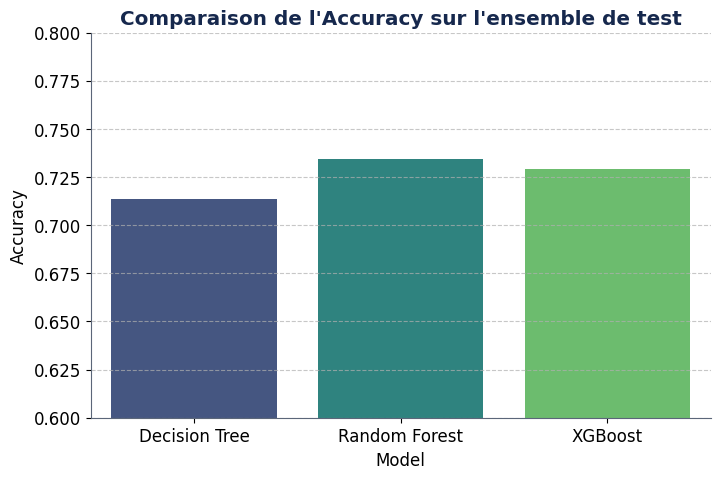

In [24]:
model_scores = {
    "Decision Tree": arbre.score(X_test, y_test),
    "Random Forest": random.score(X_test, y_test),
    "XGBoost": xgb.score(X_test, y_test)
}

df_scores = pd.DataFrame(model_scores.items(), columns=['Model', 'Test Accuracy'])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Model', y='Test Accuracy', data=df_scores, palette='viridis', ax=ax)
ax.set_title('Comparaison de l\'Accuracy sur l\'ensemble de test')
ax.set_ylabel('Accuracy')
plt.ylim(0.6, 0.8) # Set a reasonable y-limit for accuracy scores
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## A rendre
- Accuracy test + lecture de la matrice de confusion.
- Le rappel sur `diabetique` et pourquoi il est prioritaire ici.
- Les 2-3 variables les plus determinantes.

**Bonus.** Faites varier `max_depth` (2, 3, 6, None) : ou commence le surapprentissage ?